In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Shape: (200000, 202)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB
None
   ID_code  target    var_0   var_1    var_2   var_3    var_4   var_5   var_6  \
0  train_0       0   8.9255 -6.7863  11.9081  5.0930  11.4607 -9.2834  5.1187   
1  train_1       0  11.5006 -4.1473  13.8588  5.3890  12.3622  7.0433  5.6208   
2  train_2       0   8.6093 -2.7457  12.0805  7.8928  10.5825 -9.0837  6.9427   
3  train_3       0  11.0604 -2.1518   8.9522  7.1957  12.5846 -1.8361  5.8428   
4  train_4       0   9.8369 -1.4834  12.8746  6.6375  12.2772  2.4486  5.9405   

     var_7  ...  var_190  var_191  var_192  var_193  var_194  var_195  \
0  18.6266  ...   4.4354   3.9642   3.1364   1.6910  18.5227  -2.3978   
1  16.5338  ...   7.6421   7.7214   2.5837  10.9516  15.4305   2.0339   
2  14.6155  ...   2.9057   9.7905   1.6704   1.6858  21.6042   3.1417   
3  14.9250

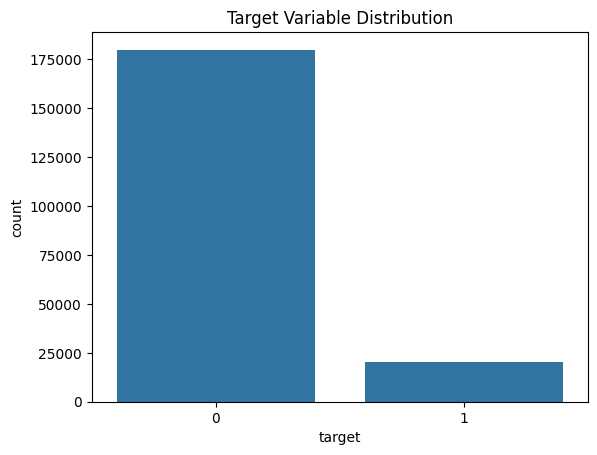

target
0    0.89951
1    0.10049
Name: proportion, dtype: float64


In [ ]:
df = pd.read_csv("train.csv")

print("Shape:", df.shape)
print(df.info())
print(df.head())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("Duplicate Rows:", df.duplicated().sum())

sns.countplot(x='target', data=df)
plt.title("Target Variable Distribution")
plt.show()

print(df['target'].value_counts(normalize=True))

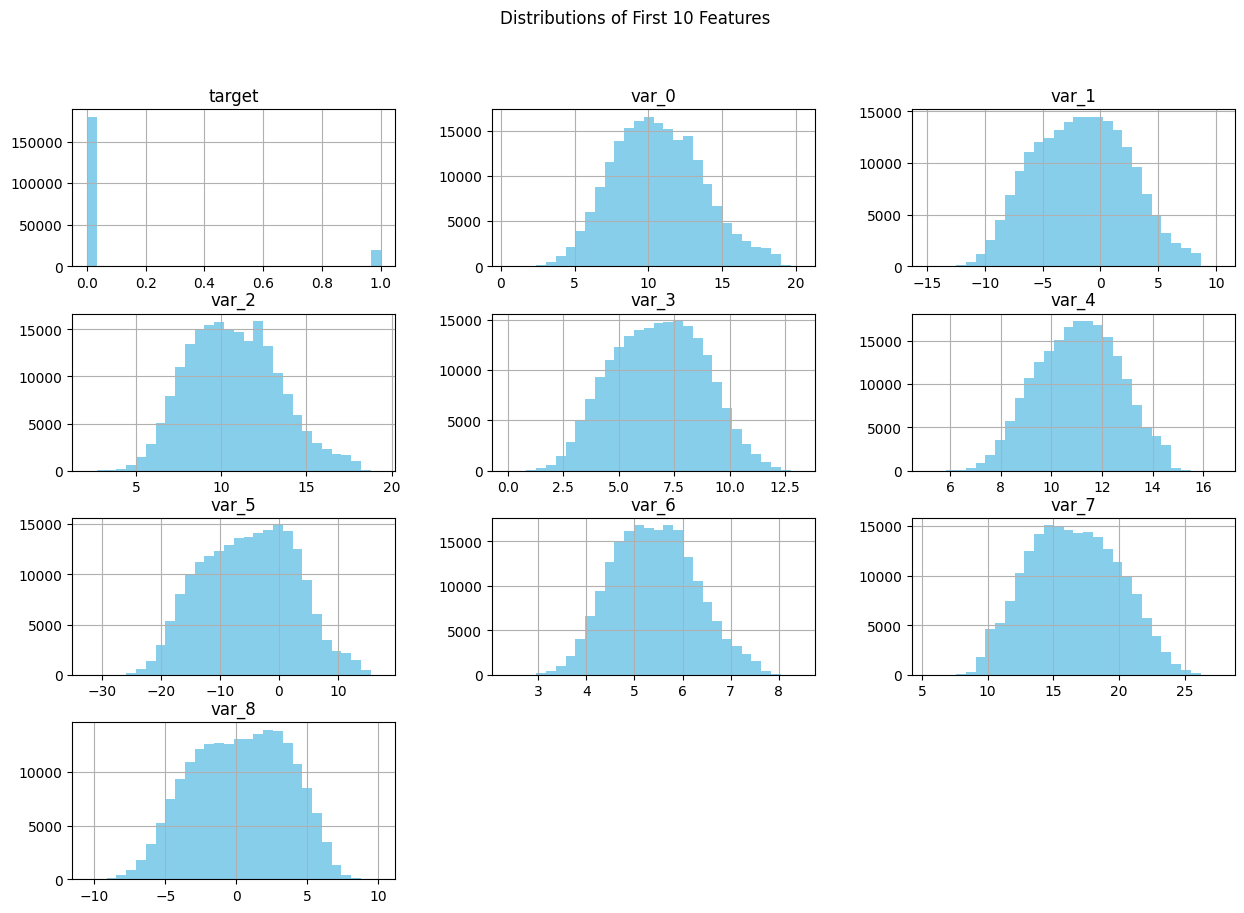

In [ ]:
df.iloc[:,1:11].hist(bins=30, figsize=(15, 10), color='skyblue')
plt.suptitle("Distributions of First 10 Features")
plt.show()

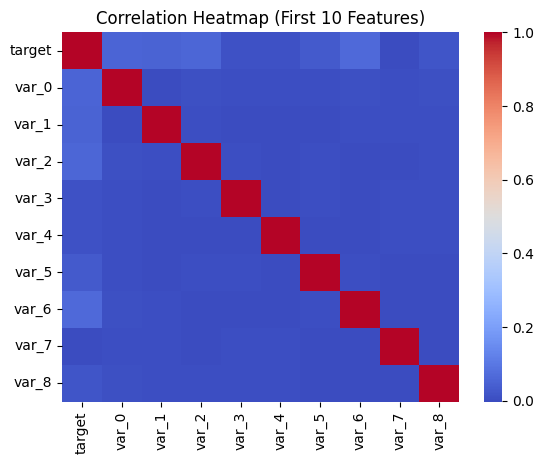

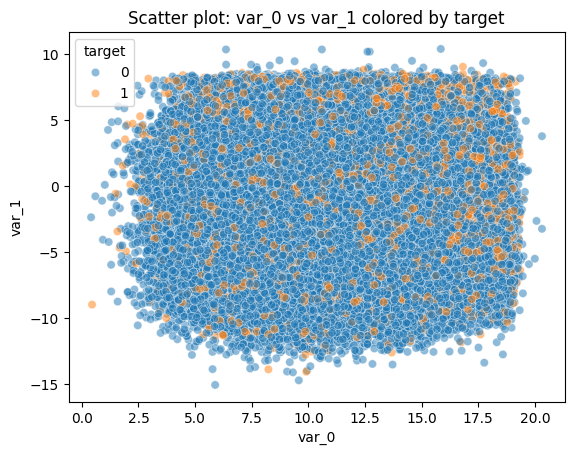

In [ ]:
subset = df.columns[1:11]
sns.heatmap(df[subset].corr(), cmap="coolwarm")
plt.title("Correlation Heatmap (First 10 Features)")
plt.show()

sns.scatterplot(data=df, x='var_0', y='var_1', hue='target', alpha=0.5)
plt.title("Scatter plot: var_0 vs var_1 colored by target")
plt.show()

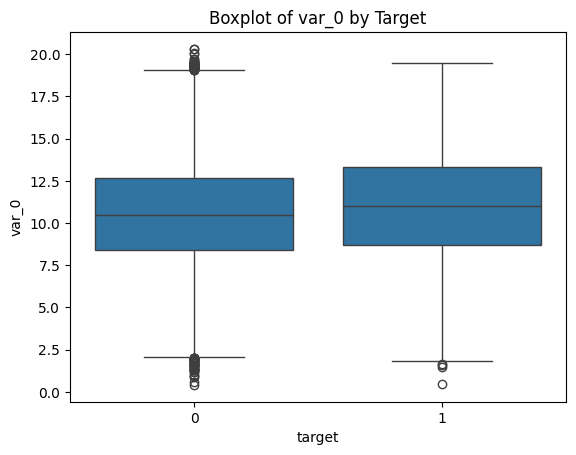

In [ ]:
sns.boxplot(data=df, x='target', y='var_0')
plt.title("Boxplot of var_0 by Target")
plt.show()

In [ ]:
import numpy as np

df.drop('ID_code', axis=1, inplace=True)

corr_matrix = df.drop('target', axis=1).corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

drop_cols = [column for column in upper.columns if any(upper[column] > 0.8)]
print("Dropping", len(drop_cols), "highly correlated columns")
df.drop(drop_cols, axis=1, inplace=True)

Dropping 0 highly correlated columns


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_.cumsum()
print("Total variance retained by 30 components:", explained_variance[-1])

Total variance retained by 30 components: 0.15799742198259067


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi_scores = mutual_info_classif(X_scaled, y)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

mi_top_30 = mi_series.head(30).index
X_mi = X[mi_top_30]

print("Top 30 MI Features:\n", mi_series.head(30))

Top 30 MI Features:
 var_81     0.004510
var_139    0.004125
var_80     0.004079
var_12     0.003801
var_53     0.002697
var_99     0.002668
var_26     0.002626
var_109    0.002542
var_133    0.002517
var_148    0.002440
var_164    0.002440
var_169    0.002367
var_110    0.002325
var_92     0.002312
var_21     0.002304
var_166    0.002286
var_0      0.002236
var_123    0.002150
var_34     0.002138
var_37     0.002133
var_108    0.002130
var_13     0.002098
var_165    0.002087
var_146    0.002050
var_147    0.002026
var_9      0.002015
var_174    0.002014
var_190    0.001927
var_191    0.001918
var_118    0.001917
dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_top_30 = importances.sort_values(ascending=False).head(30).index
X_rf = X[rf_top_30]

print("Top 30 RF Features:\n", importances.sort_values(ascending=False).head(30))

Top 30 RF Features:
 var_81     0.012749
var_12     0.009842
var_139    0.009573
var_53     0.008748
var_26     0.008680
var_110    0.008343
var_146    0.008035
var_174    0.007979
var_166    0.007977
var_109    0.007966
var_22     0.007853
var_80     0.007596
var_6      0.007580
var_99     0.007411
var_76     0.007260
var_165    0.007172
var_78     0.007155
var_133    0.007001
var_198    0.006981
var_13     0.006850
var_44     0.006766
var_190    0.006765
var_148    0.006762
var_0      0.006686
var_164    0.006619
var_179    0.006612
var_21     0.006577
var_1      0.006563
var_94     0.006560
var_2      0.006543
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(X, y, model_name):
    print(f"\n--- Evaluating {model_name} ---")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    if model_name == "RandomForest":
        model = RandomForestClassifier(n_estimators=100, random_state=42)
    elif model_name == "LogisticRegression":
        model = LogisticRegression(max_iter=1000)
    elif model_name == "DecisionTree":
        model = DecisionTreeClassifier(random_state=42)
    else:
        raise ValueError("Invalid model name")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))

    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{model_name} - ROC Curve")
    plt.show()


--- Evaluating LogisticRegression ---
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     35903
           1       0.69      0.26      0.38      4097

    accuracy                           0.91     40000
   macro avg       0.81      0.62      0.66     40000
weighted avg       0.90      0.91      0.89     40000

ROC AUC: 0.8574970373995601


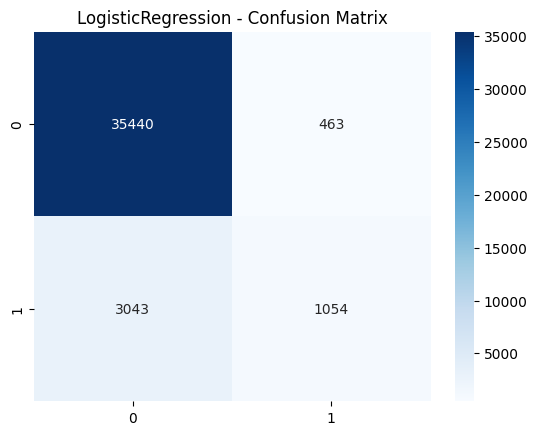

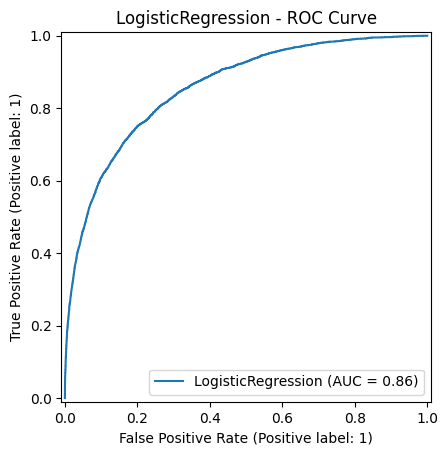


--- Evaluating RandomForest ---
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     35903
           1       0.84      0.02      0.03      4097

    accuracy                           0.90     40000
   macro avg       0.87      0.51      0.49     40000
weighted avg       0.89      0.90      0.85     40000

ROC AUC: 0.762500984825472


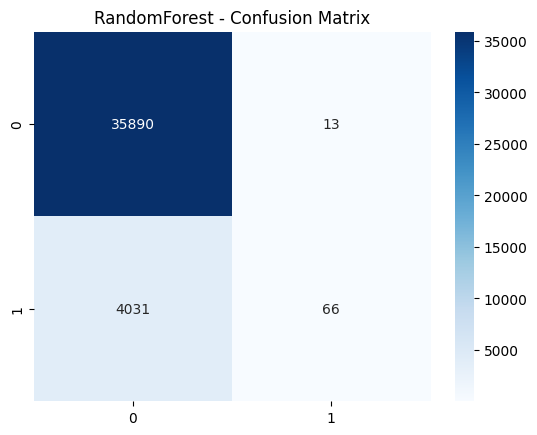

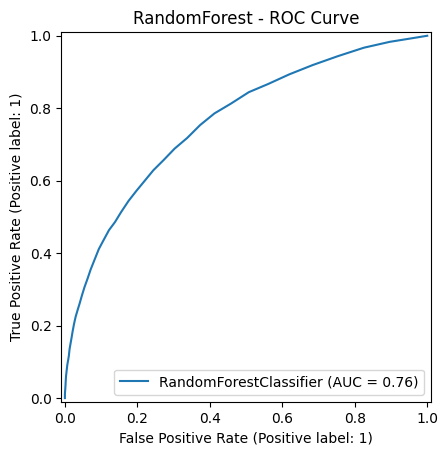


--- Evaluating DecisionTree ---
              precision    recall  f1-score   support

           0       0.91      0.90      0.91     35903
           1       0.21      0.23      0.22      4097

    accuracy                           0.83     40000
   macro avg       0.56      0.57      0.56     40000
weighted avg       0.84      0.83      0.84     40000

ROC AUC: 0.5660181583427497


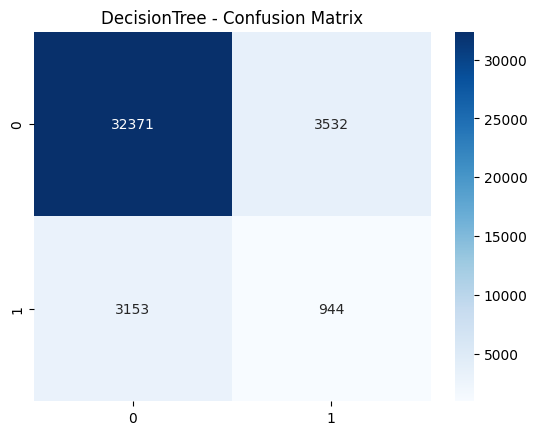

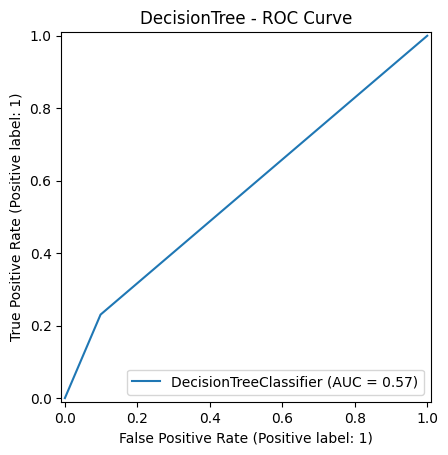

In [ ]:
evaluate_model(X_pca, y, "LogisticRegression")
evaluate_model(X_mi, y, "RandomForest")
evaluate_model(X_rf, y, "DecisionTree")

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LogisticRegression(max_iter=1000), X_pca, y, cv=5, scoring='roc_auc')
print("Cross-validated ROC AUC scores:", cv_scores)
print("Mean AUC:", cv_scores.mean())


Cross-validated ROC AUC scores: [0.85329248 0.85409026 0.85711031 0.8622842  0.86122643]
Mean AUC: 0.8576007368103549


In [ ]:
test = pd.read_csv("test.csv")
ids = test["ID_code"]
X_test_raw = test.drop("ID_code", axis=1)

X_test_scaled = scaler.transform(X_test_raw)
X_test_pca_final = pca.transform(X_test_scaled)

from sklearn.linear_model import LogisticRegression
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_pca, y)

test_preds = final_model.predict_proba(X_test_pca_final)[:, 1]
print("Test predictions shape:", test_preds.shape)

submission = pd.DataFrame({
    "ID_code": ids,
    "target": test_preds
})
submission.to_csv("submission.csv", index=False)
print("submission.csv saved!")


Test predictions shape: (200000,)
submission.csv saved!
